In [2]:
!pip install kagglehub
import kagglehub

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [4]:
# Download latest version
path = kagglehub.dataset_download("asaniczka/uk-optimal-product-price-prediction")

print("Path to dataset files:", path)

Path to dataset files: /Users/baojianing/.cache/kagglehub/datasets/asaniczka/uk-optimal-product-price-prediction/versions/3


In [5]:
import os
os.listdir(path)

['amz_uk_price_prediction_dataset.csv']

In [6]:
csv_path = os.path.join(path, 'amz_uk_price_prediction_dataset.csv')
table = pd.read_csv(csv_path)
table.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


### Part 1: Understanding Product Categories

**Business Question**: What are the most popular product categories on Amazon UK, and how do they compare in terms of listing frequency?

1. **Frequency Tables**:
    - Generate a frequency table for the product `category`.
    - Which are the top 5 most listed product categories?

2. **Visualizations**:
    - Display the distribution of products across different categories using a bar chart. *If you face problems understanding the chart, do it for a subset of top categories.*
    - For a subset of top categories, visualize their proportions using a pie chart. Does any category dominate the listings?



Frequency Tables: Generate a frequency table for the product category.

In [7]:
table['price'].isnull().sum()

np.int64(0)

In [8]:
table.describe()

,uid,stars,reviews,price,boughtInLastMonth
count,2.443651e+06,2.443651e+06,2.443651e+06,2.443651e+06,2.443651e+06
mean,1.370545e+06,2.152836e+00,4.806278e+02,8.924381e+01,2.589699e+01
std,8.160562e+05,2.194865e+00,5.944124e+03,3.456089e+02,2.404837e+02
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,6.589215e+05,0.000000e+00,0.000000e+00,9.990000e+00,0.000000e+00
50%,1.349029e+06,0.000000e+00,0.000000e+00,1.909000e+01,0.000000e+00
75%,2.060686e+06,4.400000e+00,5.900000e+01,4.599000e+01,0.000000e+00
max,2.828593e+06,5.000000e+00,1.356658e+06,1.000000e+05,5.000000e+04


In [9]:
(table['price'] == 0).sum()

np.int64(20)

In [10]:
freq_table_category = table['category'].value_counts().reset_index()
freq_table_category

,category,count
0,Sports & Outdoors,836265
1,Beauty,19312
2,"Handmade Clothing, Shoes & Accessories",19229
3,Bath & Body,19092
4,Birthday Gifts,18978
...,...,...
291,Alexa Built-In Devices,107
292,Motorbike Chassis,107
293,Plugs,107
294,Smart Home Security & Lighting,104


Which are the top 5 most listed product categories?

In [11]:
# Sports & Outdoors; Beauty; Handmade Clothing, Shoes & Accessories; Bath & Body; Birthday Gifts   

Visualizations:

Display the distribution of products across different categories using a bar chart. If you face problems understanding the chart, do it for a subset of top categories.
For a subset of top categories, visualize their proportions using a pie chart. 

Text(0.5, 1.0, 'top 10 categories')

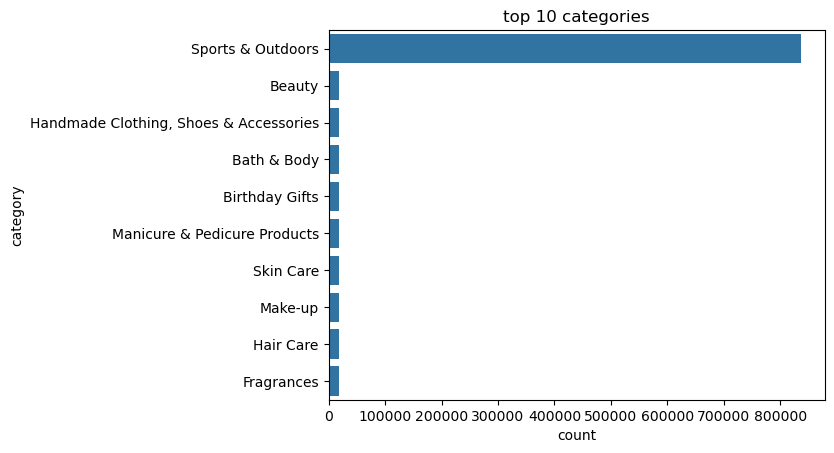

In [12]:
# create a sub
top10_ca=freq_table_category.head(10)
top10_ca
sns.barplot(data = top10_ca, y='category', x='count')
plt.title('top 10 categories')

In [13]:
import matplotlib.pyplot as plt

In [14]:
type(plt.ylabel)

function

<Figure size 1200x600 with 0 Axes>

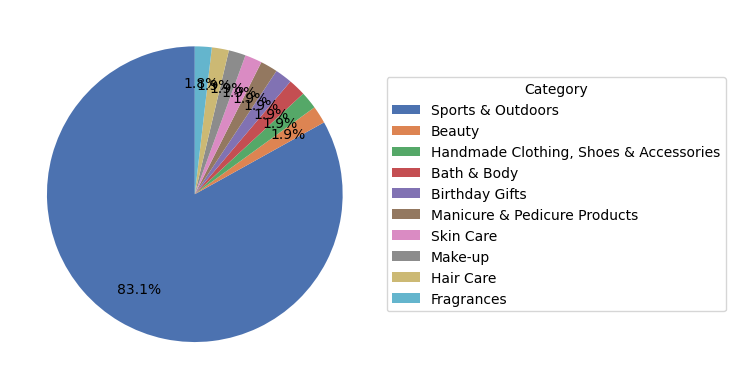

In [15]:
plt.figure(figsize=(12, 6))
top10_ca.plot.pie(y='count', labels= None, autopct= '%.1f%%', pctdistance = 0.75, startangle = 90, colors = sns.color_palette('deep'))
plt.ylabel('')
plt.legend(labels = top10_ca['category'], title = 'Category', loc = 'center left', bbox_to_anchor=(1, 0.5))
plt.show()

Does any category dominate the listings?

Yes, Sports&Outdoors.

### Part 2: Delving into Product Pricing

**Business Question**: How are products priced on Amazon UK, and are there specific price points or ranges that are more common?

1. **Measures of Centrality**:
    - Calculate the mean, median, and mode for the `price` of products.
    - What's the average price point of products listed? How does this compare with the most common price point (mode)?

2. **Measures of Dispersion**:
    - Determine the variance, standard deviation, range, and interquartile range for product `price`.
    - How varied are the product prices? Are there any indicators of a significant spread in prices?

3. **Visualizations**:
    - Is there a specific price range where most products fall? Plot a histogram to visualize the distribution of product prices. *If its hard to read these diagrams, think why this is, and explain how it could be solved.*.
    - Are there products that are priced significantly higher than the rest? Use a box plot to showcase the spread and potential outliers in product pricing. 


In [16]:
table.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [17]:
print(
    f"mean is  {table['price'].mean()}, mode is  {table['price'].mode()}, median is {table['price'].median()}"
)

mean is  89.24380943923661, mode is  0    9.99
Name: price, dtype: float64, median is 19.09


In [18]:
#cal variance
vari_price = table['price'].var()
#cal std deviation
stdDev_price = table['price'].std()
#find range 
range_price = table['price'].max() - table['price'].min()
#Interquartile Range (IQR)
price_q25 = table['price'].quantile(0.25)
price_q75 = table['price'].quantile(0.75)
iqr_price = price_q75 - price_q25
#print
print(f'variance is {vari_price}')
print(f'standard deviation is {stdDev_price}')
print(f'Range is {range_price}')
print(f'IQR is {iqr_price}')

variance is 119445.4853225653
standard deviation is 345.6088617535223
Range is 100000.0
IQR is 36.0


Are there any indicators of a significant spread in prices?

Yes, the range is extreme large, there are some outliers.

<Axes: xlabel='price', ylabel='Count'>

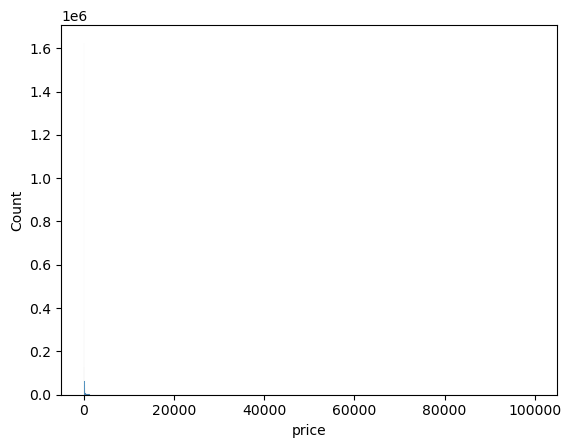

In [30]:
# visualization
#Is there a specific price range where most products fall? 

# Plot a histogram to visualize the distribution of product prices. 
sns.histplot(data= table, x='price')

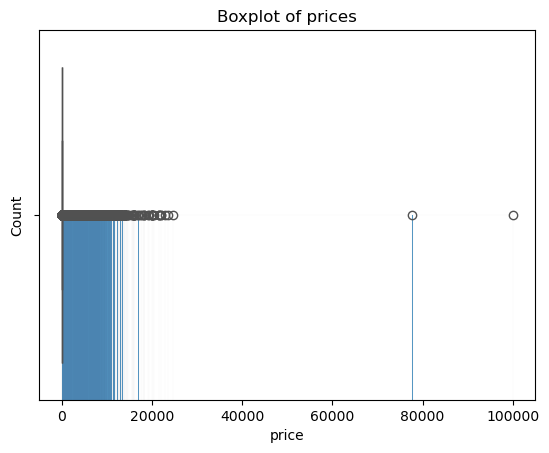

In [ ]:
# If its hard to read these diagrams, think why this is, and explain how it could be solved.*.
#because outliers.

# Are there products that are priced significantly higher than the rest? 
# Yes. 
# 
# 
# Use a box plot to showcase the spread and potential outliers in product pricing. 
sns.boxplot(x=table['price'])
plt.title("Boxplot of prices")
plt.show()


### Part 3: Unpacking Product Ratings

**Business Question**: How do customers rate products on Amazon UK, and are there any patterns or tendencies in the ratings?

1. **Measures of Centrality**:
    - Calculate the mean, median, and mode for the `rating` of products.
    - How do customers generally rate products? Is there a common trend?

2. **Measures of Dispersion**:
    - Determine the variance, standard deviation, and interquartile range for product `rating`.
    - Are the ratings consistent, or is there a wide variation in customer feedback?

3. **Shape of the Distribution**:
    - Calculate the skewness and kurtosis for the `rating` column. 
    - Are the ratings normally distributed, or do they lean towards higher or lower values?

4. **Visualizations**:
    - Plot a histogram to visualize the distribution of product ratings. Is there a specific rating that is more common?

In [20]:
table.head(10)

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers
5,6,B09B97WSLF,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
6,7,B09B9615X2,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
7,8,B01MTB55WH,Anker Soundcore 2 Portable Bluetooth Speaker w...,4.7,103673,39.99,False,0,Hi-Fi Speakers
8,9,B016MO90GW,"Bluetooth Speaker, Anker Soundcore Speaker Upg...",4.7,29909,29.99,False,0,Hi-Fi Speakers
9,10,B09ZQF5GZW,RIENOK Bluetooth Speaker Portable Wireless Blu...,4.5,16014,29.99,False,0,Hi-Fi Speakers


In [21]:
# we need to remove the 0 review and 0 star
rating = table[table['stars']> 0]
rating.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [22]:
print(
    f"mean is  {rating['stars'].mean()}, mode is  {rating['stars'].mode()}, median is {rating['stars'].median()}"
)

mean is  4.319160762226911, mode is  0    4.5
Name: stars, dtype: float64, median is 4.4


In [23]:
# Mean is not far away from median, customers tend to give 4 stars.

In [24]:
vari_rating = rating['stars'].var()
stdDev_rating = rating['stars'].std()
iqr_rating = rating['stars'].quantile(0.75)-rating['stars'].quantile(0.25)
#print
print(f'variance is {vari_rating}')
print(f'standard deviation is {stdDev_rating}')
print(f'IQR is {iqr_rating}')

variance is 0.30834337523805183
standard deviation is 0.5552867504614637
IQR is 0.5


In [25]:
#No, there is no huge variance. 

In [26]:
rat_skew = rating['stars'].skew()
rat_kur = rating['stars'].kurtosis()
print(f'Skewness of rating is {rat_skew} and kurtosis of rating is {rat_kur}')

Skewness of rating is -2.379568112212799 and kurtosis of rating is 9.78193769066435


In [27]:
# toward lower value because skewness is negative.

<Axes: xlabel='stars', ylabel='Count'>

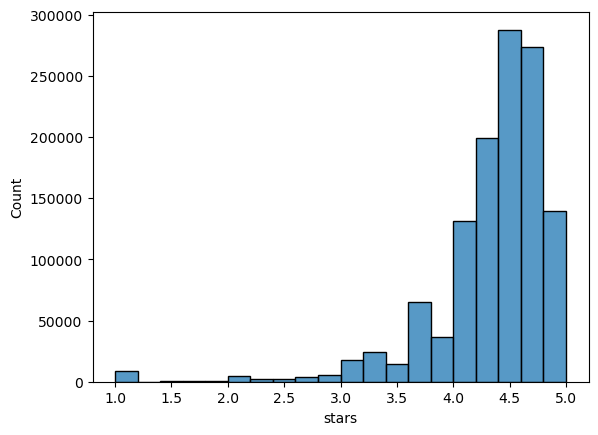

In [ ]:
#**Visualizations**:-
# Plot a histogram to visualize the distribution of product ratings. Is there a specific rating that is more common?

sns.histplot(data= rating, x='stars', bins=20)



Final conclusion：

After analyzing the data was given, we can see that among the categories, Sport & Outdoors are the most frequently ordered items, is even dominant compared to others. Among the top 10 categories, Sports & Outdoors takes the first position with 83.1%. Considering the price, the average of price is  89.24, while the most appeared price is 9.99, which indicates the extreme high price in the dataset. It can be also obtained from boxplot, the extreme value locate around 70000 - 1000000. If we look at the distribution of review and rating, it is obviously that the most customers would give 4 stars and 5 stars, less stars would rarely be seen. 
